# Three NMPC loops on the Hicks-Ray CSTR

Nonlinear model predictive control (NMPC) measures the state at every
sample, solves an optimization over a horizon from that state, and
implements the first move of the solution. The solve takes time, and the
three loops on this page differ in what they do about that time.
`drto.ideal_nmpc` assumes the solve takes none. `drto.nonideal_nmpc`
puts the solve time into the loop as a delay. `drto.asnmpc`, the
advanced-step controller of Huang, Zavala, and Biegler (2009), runs the
solve during the sampling interval, before the measurement arrives, so
that no delay is left.

This page runs all three on the Hicks-Ray CSTR from
[`models/hicks.py`](models/hicks.py), with the delay set at 90% of the
sampling interval, first without disturbances and then under process
noise.

## The three loops

Write $x_k$ for the state measured at the sample time $t_k$, $h$ for the
sampling interval, $w_k$ for the disturbance over the interval that
starts at $t_k$, and $\kappa(x)$ for the first move of the horizon
problem solved from the state $x$.

The ideal loop implements the move at the instant of the measurement,

$$u_k = \kappa(x_k) \quad \text{over} \quad [t_k,\ t_{k+1}).$$

The nonideal loop solves the same problem, and the move takes effect one
delay $d$ later. The previous move holds until then,

$$u_{k-1} \ \text{over} \ [t_k,\ t_k + d), \qquad
u_k = \kappa(x_k) \ \text{over} \ [t_k + d,\ t_{k+1}).$$

The advanced-step loop does its solve during the interval instead of at
the measurement. It simulates the model one sample ahead under the
current move and zero disturbance, which gives the predicted state
$\hat x_{k+1}$, and it solves the horizon problem from $\hat x_{k+1}$
during that interval. When $x_{k+1}$ is measured, the loop
corrects the finished solution to it with the sensitivity of the
solution to its initial state,

$$u_{k+1} = \kappa(\hat x_{k+1}) +
\frac{\partial \kappa}{\partial x}\bigg|_{\hat x_{k+1}}
\left(x_{k+1} - \hat x_{k+1}\right).$$

The correction is one linear solve with the matrix factorization the
horizon solve already computed, so the move is implemented at the
measurement. With no disturbance the prediction equals the measurement,
the correction is zero, and the loop implements the ideal loop's moves.
Under a disturbance the corrected move is a first-order approximation of
$\kappa(x_{k+1})$.

## The model and the setup

The Hicks-Ray CSTR has two states, the concentration `zc` and the
temperature `zt`, and two controls, the coolant flow `v1` and the
residence time `v2`, all dimensionless. `hicks(disturbance=True)` adds a
disturbance to each balance, `w_c` and `w_t`, which the controller holds
at zero and the process draws at every step.

Every loop takes the same options. The sampling interval is `H`, the
nonideal loop's delay is `DELAY`, and the controller's horizon ends in
the terminal segment of `drto.infinite_horizon`.

In [1]:
from functools import partial

import matplotlib.pyplot as plt

import drto
from models.hicks import hicks

H = 1                # the sampling interval
DELAY = 0.9 * H     # the nonideal loop's delay
STEPS = 50

options = dict(steps=STEPS, h=H, dynamic_optimization={"infinite_horizon": True})


def run_loops(build, **kwds):
    "Run the three loops on one model statement with the same options."
    return {
        "ideal": drto.ideal_nmpc(build, **options, **kwds),
        "advanced-step": drto.asnmpc(build, **options, **kwds),
        "nonideal": drto.nonideal_nmpc(build, delay=DELAY, **options, **kwds),
    }


def report(histories):
    "Print each loop's largest gap from the ideal loop and its distance to the targets."
    ideal = histories["ideal"]
    print(f"{'loop':15s}{'largest state gap':>19s}{'at time':>9s}{'largest move gap':>19s}"
          f"{'squared distance':>19s}")
    for name, hist in histories.items():
        state_gap, at = max((abs(p - q), t) for key in hist.states
                            for p, q, t in zip(hist.states[key], ideal.states[key], hist.times))
        move_gap = max(abs(p - q) for key in hist.moves
                       for p, q in zip(hist.moves[key], ideal.moves[key]))
        distance = sum((x - hist.state_targets[key]) ** 2
                       for key in hist.states for x in hist.states[key])
        when = f"{at:g}" if state_gap > 0 else "-"
        print(f"{name:15s}{state_gap:19.3g}{when:>9s}{move_gap:19.3g}{distance:19.4g}")


def draw(histories):
    "Overlay the loops, the states at the samples and the moves as staircases."
    ideal = histories["ideal"]
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
    # one style per loop, in the order run_loops returns them
    styles = dict(zip(histories, (("C0", "-"), ("C1", "--"), ("C3", "-"))))
    for ax, key in zip(axes[0], ideal.states):
        for name, hist in histories.items():
            color, line = styles[name]
            ax.plot(hist.times, hist.states[key], line, color=color, marker=".", label=name)
        ax.axhline(ideal.state_targets[key], color="k", linestyle=":", label="target")
        ax.set_ylabel(key)
    for ax, key in zip(axes[1], ideal.moves):
        for name, hist in histories.items():
            color, line = styles[name]
            effects = getattr(hist, "effect_times", None)
            if effects:
                # the declared target holds until the first move takes effect
                t = [hist.times[0]] + list(effects) + [hist.times[-1]]
                u = [hist.control_targets[key]] + hist.moves[key] + [hist.moves[key][-1]]
            else:
                t, u = hist.times, hist.moves[key] + [hist.moves[key][-1]]
            ax.step(t, u, line, where="post", color=color, label=name)
        ax.axhline(ideal.control_targets[key], color="k", linestyle=":", label="target")
        ax.set_ylabel(key)
        ax.set_xlabel("time")
    axes[0][0].legend()
    fig.tight_layout()
    return axes

## Without disturbances

The process here is the controller's own model, so the advanced-step
prediction is exact. The table gives each loop's largest gap from the
ideal loop over the states and over the moves, the time of the largest
state gap, and the squared distance of the states from their targets,
summed over the states and the samples,
$\sum_k \sum_i \left(x_{i,k} - x_i^{ss}\right)^2$.

In [2]:
quiet = run_loops(hicks)
report(quiet)

loop             largest state gap  at time   largest move gap   squared distance
ideal                            0        -                  0           0.002069
advanced-step             1.44e-10       47           5.37e-10           0.002069
nonideal                   0.00389        2             0.0406           0.002096


The advanced-step loop implements the ideal loop's moves to within
$10^{-9}$. The nonideal loop's largest state gap, 0.0039, is at $t = 2$.
For the first 90% of the first interval the process holds the declared
control targets, the inputs it had before the loop started, and they are
far from the first move the controller solves for. The temperature falls
over that interval where the ideal loop raises it, and over the next
samples the nonideal loop's moves differ from the ideal loop's by up to
0.041. Every later move takes effect 0.9 of an interval after the ideal
loop's. All three loops settle at the targets within the 50 samples, and
the nonideal loop's squared distance to the targets is 1.3% larger than
the ideal loop's.

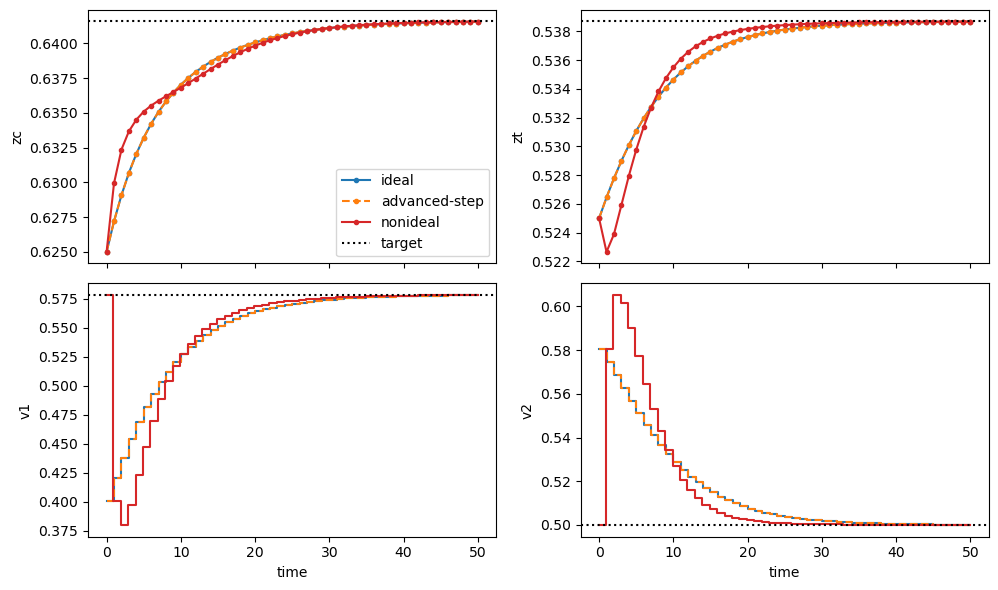

In [3]:
axes = draw(quiet)

## Under process noise

Each disturbance is drawn at every step from a zero-mean normal
distribution with the standard deviation below, and the seed makes the
three loops see the same draws. The advanced-step loop now corrects a
prediction that missed, and the nonideal loop holds a move that was
solved before the last disturbance arrived.

In [4]:
NOISE = {"w_c": 0.001, "w_t": 0.001}

noisy = run_loops(partial(hicks, disturbance=True), disturbances=NOISE, seed=7)
print("same draws:", all(h.realizations == noisy["ideal"].realizations for h in noisy.values()))
moved = max(abs(p - q) for key in noisy["ideal"].states
            for p, q in zip(noisy["ideal"].states[key], quiet["ideal"].states[key]))
print(f"the noise moves the ideal loop's states by at most {moved:.3g}")
print()
report(noisy)

same draws: True
the noise moves the ideal loop's states by at most 0.00485

loop             largest state gap  at time   largest move gap   squared distance
ideal                            0        -                  0           0.002364
advanced-step             7.63e-05       50           0.000941           0.002369
nonideal                    0.0038        1             0.0402           0.002478


The noise moves the ideal loop's states by at most 0.0049. Against that,
the advanced-step loop's states stay within 0.000076 of the ideal loop's
and its moves within 0.00094, which is the error of the first-order
correction. The nonideal loop's largest state gap is 0.0038 at $t = 1$,
the end of the first interval, and its moves differ from the ideal
loop's by up to 0.040. Its squared distance to the targets is 4.8%
larger than the ideal loop's, and the advanced-step loop's is 0.2%
larger.

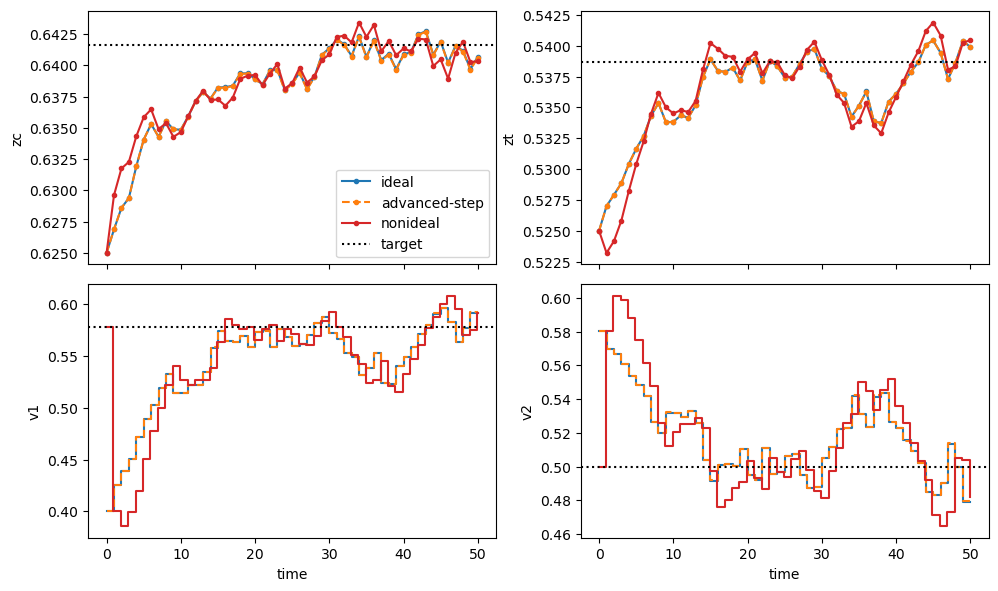

In [5]:
axes = draw(noisy)